## MCP, Deployment & Production AI Systems

---

### Overview & Scope

This section transitions focus to advanced integration patterns, Model Context Protocol (MCP) implementations, and the structural requirements for deploying reliable, production-grade AI systems at scale.

> **Core Focus**: Bridging agentic runtime environments with standardized external protocols to streamline enterprise deployment, security boundaries, and tool orchestration.
> 
>

## Why Glue Code Fails at Scale

Most AI prototypes start the same way: a handful of Python scripts, hardcoded API keys, and ad-hoc integrations duct-taped together until something works. While this approach gets demos shipped quickly, it becomes a severe liability in production.

---

### Tightly Coupled Scripts vs. Modular Systems

* **Tightly Coupled Scripts**:


* A single change breaks multiple downstream components.


* There are no clear boundaries between logic, data, and I/O.


* Secrets and configurations are scattered across files.


* Components are impossible to test in isolation.


* The architecture scales only by copy-pasting.




* **Modular, Protocol-Driven Systems**:


* Components communicate through well-defined interfaces.


* Each service owns its own context and responsibility.


* Authentication and access are enforced at clear boundaries.


* Services are testable, deployable, and observable independently.


* The system scales horizontally without requiring architectural rewrites.





> **Production Takeaway**: Glue code is a prototype strategy, not a production strategy. The cost of rewiring a fragile system at scale is far greater than building with modularity from day one.
> 
>

## What Is Model Context Protocol (MCP)?

Model Context Protocol (MCP) functions as the context orchestration layer sitting between your AI model and the rest of your system. Instead of letting the LLM directly call tools, query databases, or reach into memory in an uncontrolled manner, MCP mediates every interaction to provide a structured, auditable, and secure bridge.

---

### The Three Layers of MCP Architecture

* **The Model Layer**: The LLM generates structured requests—such as tool calls, memory lookups, and data queries—expressed purely as intent rather than raw execution commands.


* **MCP: The Orchestration Bridge**: MCP validates, routes, and scopes every request, enforcing strict permissions, resolving context, and mediating access to downstream systems.


* **The Systems Layer**: External APIs, databases, vector stores, and tools respond exclusively to well-formed, authorized requests that have passed securely through the MCP boundary.

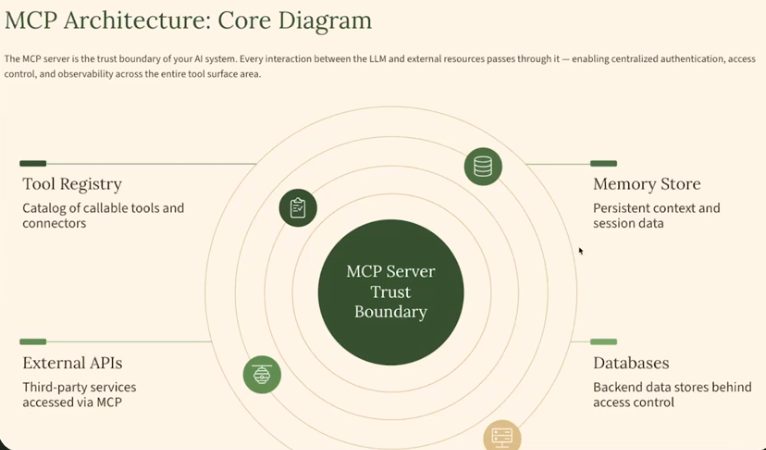

## Context Flow in a Modern AI System

Understanding *how context moves* through an MCP-powered system is essential for building reliable, predictable AI products. Each step in the flow represents a distinct responsibility—and a potential failure point if it is not handled properly.

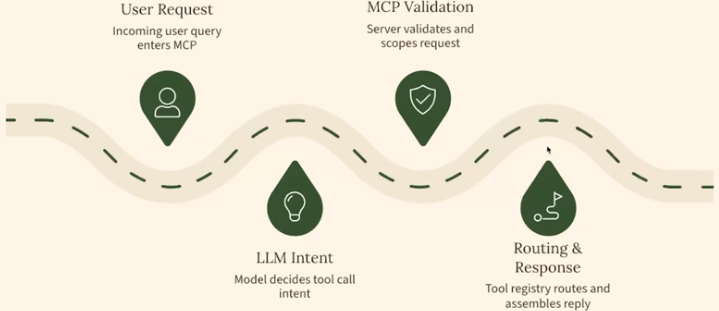

## Context Flow in a Modern AI System: Step-by-Step Architecture

Understanding how context moves through an MCP-powered system is vital for keeping applications reliable and predictable. Each stage represents a distinct responsibility and a potential failure point if mismanaged.

---

### The Five Stages of Context Flow

* **Request**:
* User input enters the system and is contextualized by the LLM.




* **Intent**:
* The LLM expresses structured intent, such as a tool call or memory query.




* **Validation**:
* MCP checks permissions, scopes, and request well-formedness.




* **Execution**:
* The authorized tool or data source is invoked with bounded access.




* **Assembly**:
* Results are returned, validated, and injected back into the model context.


## Security Risks in AI Systems

Production AI systems introduce unique attack surfaces that traditional software does not face. The dynamic, context-driven nature of LLMs makes them vulnerable to specialized threats that standard firewalls and auth layers fail to address.

---

### Key Security Threats

* **Prompt Injection**:
* Malicious input hidden within user data or external tool responses hijacks model instructions.


* This overrides system prompts and triggers unintended actions.




* **Context Leakage**:
* Sensitive data injected into the model context—such as PII, API keys, or internal configurations—can be exfiltrated through crafted completions or logged outputs.




* **Unsafe Tool Access**:
* Without strictly scoped permissions, an LLM granted tool access can invoke destructive endpoints, delete records, or exfiltrate data at model speed.




* **Privilege Escalation**:
* Chained tool calls can compound permissions beyond what any single step would allow, enabling unintended access to restricted systems.

## Access Control & Safe Tooling

MCP enforces a scoped permission model between the agent and every tool or data resource it can access. This is what separates a production AI system from a prototype—not just what the model can do, but what it's allowed to do in a given context.

---

### MCP Permission Layers

* **01. Identity & Authentication**: Every agent request is authenticated to ensure there are no anonymous tool calls.


* **02. Role-Based Tool Scoping**: Agents receive only the specific tools their role requires rather than the full registry.


* **03. Request Validation**: Tool call parameters are validated against defined schemas prior to execution.


* **04. Audit Logging**: Every tool invocation is recorded with context, actor, and outcome.



---

### Tooling Safety Principles

* **Least privilege**: Grant the minimum access required to complete the task.


* **Explicit allow-lists**: Deny by default and permit by exception.


* **Read/write separation**: Differentiate read-only queries from mutating operations.


* **Rate limiting**: Prevent runaway tool calls from looping agents.


* **Human-in-the-loop gates**: Require explicit confirmation for high-risk actions.


* **Sandboxed execution**: Run tool code within isolated, ephemeral environments.



> **Production Takeaway**: Safe tooling is not a feature—it's a prerequisite. Ship it before the first external user ever touches the system.
> 
>

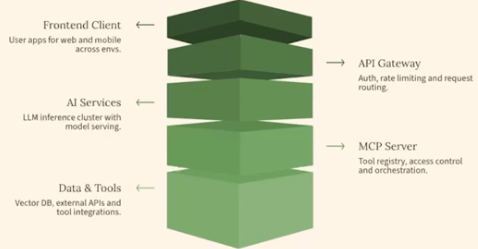

## Production AI Deployment Architecture

A production-grade AI system is more than just a model behind an endpoint. It is a layered architecture spanning user-facing services, secure AI backends, data infrastructure, and the operational systems that keep everything observable, deployable, and recoverable.

---

### Core Stack Components

* **Frontend Client**: User applications for web and mobile across environments.


* **API Gateway**: Handles authentication, rate limiting, and request routing.


* **AI Services**: Consists of an LLM inference cluster with model serving.


* **MCP Server**: Manages the tool registry, access control, and context orchestration.


* **Data & Tools**: Integrates vector databases, external APIs, and tool integrations.

## CI/CD for AI Systems

AI systems introduce new artifacts into the CI/CD pipeline—not just code and configs, but model weights, prompt templates, vector index snapshots, and tool schemas. Each must be versioned, tested, and promoted through environments with the same rigor as application code.

---

### What Gets Versioned

* Application code and dependencies.


* Prompt templates and system instructions.


* MCP tool schemas and permission configs.


* Model identifiers and inference parameters.


* Vector index snapshots and embedding configs.



---

### AI-Specific Test Gates

* Prompt regression tests against golden outputs.


* Tool schema validation before registry update.


* Latency and cost benchmarks per model change.


* Security scan for prompt injection vectors.


* Canary rollout with real-traffic evaluation.

## Monitoring & Observability

Observability in AI systems goes far beyond standard uptime tracking. You need deep visibility into model behavior, tool usage patterns, cost per request, and data quality because silent failures are the most dangerous kind in systems that speak fluent natural language.

---

### Core Pillars of AI Observability

* **Latency Tracking**: Monitor p50, p95, and p99 latency per model call, tool invocation, and end-to-end request. Tracking these metrics surfaces infrastructure bottlenecks before users even notice.


* **Error & Exception Rates**: Track model refusals, tool call failures, schema validation errors, and timeout rates. Correlating spikes in these errors with recent deployments or upstream changes is essential for rapid debugging.


* **Cost per Request**: Token consumption, tool call frequency, and vector database reads all carry real financial implications. Real-time cost tracking prevents runaway spend caused by inefficient prompts or looping agents.


* **Tool Usage Analytics**: Audit which tools are called, by which agents, and with what parameters. Anomalous usage patterns often act as early warning signs for prompt injection attempts or misconfigured permissions.



> **Production Takeaway**: If you can't observe it, you can't operate it. Instrument every layer before going to production—never wait until after the first major incident.
> 
>

## Failure Modes in Production AI

AI systems fail in ways that are harder to detect than traditional software, as failures are often silent, probabilistic, or manifested as subtly wrong outputs rather than hard crashes. Knowing where systems break is the first step to building them not to.

---

### Common Production Failure Modes & Mitigations

* **Model Timeouts**: Inference latency spikes under load—especially with large context windows—which can block the entire request pipeline if unmanaged.


* **Mitigation**: Async tool calls, streaming responses, and circuit breakers.




* **Vector DB Failures**: Stale indexes, embedding drift, or retrieval latency degradation cause the model to operate on outdated or irrelevant context.


* **Mitigation**: Index health checks, freshness TTLs, and fallback to keyword search.




* **Tool Execution Errors**: External APIs return errors, schema mismatches, or unexpected payloads, leading the LLM to hallucinate a recovery rather than escalating.


* **Mitigation**: Strict output validation, retry logic with backoff, and error injection testing.




* **Agent Loops**: Agents that fail to converge can loop indefinitely, burning tokens and budget.


* **Mitigation**: Step limits, loop detection heuristics, and hard cost ceilings per session.




* **Context Window Overflow**: Unbounded memory injection or tool response accumulation exceeds the model's context limit, causing the truncation of critical instructions.


* **Mitigation**: Context budget management, summarization pipelines, and sliding window strategies.

## What AI System Design Interviews Look For

Senior AI engineering interviews evaluate your ability to reason about systems under real-world constraints—not just whether you can prompt an LLM. Interviewers are probing for **architecture clarity**, explicit **trade-off reasoning**, and production-grade thinking on reliability and security.

---

### Key Evaluation Pillars

* **1. Clear Component Boundaries**: Can you articulate what each layer owns? LLM, MCP, tools, data, and infra should have distinct responsibilities. Blurry boundaries signal prototype thinking.


* **2. Explicit Trade-off Reasoning**: Every design choice has a cost. Latency vs. accuracy, cost vs. freshness, simplicity vs. extensibility—name the trade-offs before the interviewer does.


* **3. Reliability by Design**: Show you've thought about failure modes, retries, fallbacks, and degraded-mode behavior. Production systems fail—engineers who anticipate failure get hired.


* **4. Security at Every Layer**: Prompt injection, access control, data leakage—security should be woven into your architecture, not bolted on at the end. Name the threats and the mitigations.